# Point 3, Decision Support, Pipeline With Point One's Signal

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. Bringing In Point One's Signal](#sec3)
- [4. Blending It Into RISK_SCORE](#sec4)
- [5. Same Policy, Two Inputs, Side By Side](#sec5)
- [6. How Much Would These Numbers Move](#sec6)
- [7. Saving The Standardized Result](#sec7)
- [8. Takeaways](#sec8)

<a id="sec1"></a>

## 1. The Problem And This Approach

Every approach notebook in this project so far answers one of Point 3's questions on its own, using only final.csv and the placeholder RISK_SCORE. This notebook is a first, thin step toward an actual pipeline, one where an earlier stage's output becomes a later stage's input, tested here on the cheapest interval policy found so far, snapshot adaptive, before Point 2's real HAZARD_ESTIMATE exists to carry this properly.

Point 1, the anomaly detection track, has two methods. Method A scores 464 patients once each, cross sectional, no visit history. Method B scores 9922 visits across 2093 patients with a health index, `HI`, the same per visit grain this notebook's own data already has, so Method B is the one used here. Point 1's own key, `RID` plus a raw `VISCODE2` code such as `sc` for a baseline visit, does not line up with `final.csv`'s own `VISCODE2_norm`, such as `bl` for the same baseline visit. Rather than a brittle string match on visit code, this notebook merges by `RID` plus nearest exam date instead, the same asof technique `rul_model_1.py` already uses internally to attach its own MRI, PET, and CSF readings to a visit.

Read this as a documented approximation, not the finished architecture. The real destination is Point 2's hazard model taking Point 1's anomaly score as an input feature alongside the raw biomarkers, with Point 3 then reading whatever HAZARD_ESTIMATE comes out the other side. Blending HI directly into Point 3's own placeholder RISK_SCORE, as done below, is a stand in for that, useful for an early answer to one question, does an upstream signal change this policy's recommendation at all, without waiting on Point 2 to be built first.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
anomaly_hi_path = os.path.join('..', '..', 'notebooks', 'anomaly_detection', 'method_b_autoencoder_hi', 'hi_trajectories.csv')
results_path = os.path.join('..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)

<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, the same merged table every other approach notebook in this project uses, one row per patient per visit, keyed by RID and the normalized visit code. HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, SUMMARY_SUVR, ABETA_RATIO, TAU, and PTAU are forward filled per patient, carrying each patient's most recently known value forward to later visits, so a visit without a fresh scan or panel can still be scored using the last one that was taken.

RISK_SCORE itself is a placeholder standing in for Point 2's own risk score, built from DIAGNOSIS and AMYLOID_STATUS alone until a real HAZARD_ESTIMATE exists to swap in, marked SWAP POINT in the code below. The subject level split into train and test happens further down, after Point 1's signal has been merged in, so the same rows can be evaluated with and without that signal side by side on identical patients.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

# SWAP POINT: once point two exists, replace this line with
#   data['RISK_SCORE'] = data['HAZARD_ESTIMATE']
data['RISK_SCORE'] = du.placeholder_risk_score(data)

<a id="sec3"></a>

## 3. Bringing In Point One's Signal

Reads Method B's per visit health index and attaches it to this notebook's own rows by `RID` plus nearest exam date, a 180 day window, the same match window `rul_model_1.py` already uses for its own biomarker matching. A row whose `RID` never appears in Method B's output, or whose nearest visit falls outside that window, keeps `HI` missing rather than a guessed value, and is reported below as the coverage this signal actually reaches.

In [3]:
anomaly_hi = pd.read_csv(anomaly_hi_path, usecols=['RID', 'EXAMDATE', 'HI'])
anomaly_hi['EXAMDATE'] = pd.to_datetime(anomaly_hi['EXAMDATE'])
anomaly_hi = anomaly_hi.sort_values('EXAMDATE').drop_duplicates(['RID', 'EXAMDATE'], keep='first')

# merge_asof needs a fully dated, sorted left side. A small number of rows,
# well under one percent, carry no parseable EXAMDATE_DX at all, those are
# set aside here and rejoined right after with HI left missing, rather than
# silently dropped from the cohort every other approach notebook uses.
has_date = data['EXAMDATE_DX'].notna()
dated, undated = data[has_date].sort_values('EXAMDATE_DX'), data[~has_date]
print(f'Rows with no EXAMDATE_DX at all, set aside from the date match: {len(undated)}')

dated = pd.merge_asof(
    dated, anomaly_hi,
    left_on='EXAMDATE_DX', right_on='EXAMDATE', by='RID',
    direction='nearest', tolerance=pd.Timedelta(days=180),
)
undated = undated.copy()
undated['EXAMDATE'] = pd.NaT
undated['HI'] = np.nan
data = pd.concat([dated, undated], ignore_index=True)

hi_coverage = data['HI'].notna().mean()
print(f'Rows with a Method B health index within 180 days: {hi_coverage:.1%}')

Rows with no EXAMDATE_DX at all, set aside from the date match: 56
Rows with a Method B health index within 180 days: 67.1%


<a id="sec4"></a>

## 4. Blending It Into RISK_SCORE

The subject level split into train and test happens first in the cell below, random_state=42 like every other approach notebook, now applied after the health index merge so both splits already carry HI wherever a match existed.

For every row where a match exists, RISK_SCORE_PIPELINE is an 80 percent, 20 percent blend of the placeholder score and HI, HI rescaled first against this notebook's own train split, the 5th to 95th percentile clipped to [0, 1], so one extreme visit cannot dominate the blend. A row with no match keeps its plain placeholder score unchanged rather than a guessed contribution. 20 percent is a documented assumption, the same order of weight the placeholder score already gives its own amyloid component, not a fitted value, and worth trying at other weights later.

In [4]:
train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

PIPELINE_WEIGHT = 0.2
hi_lo, hi_hi = train_df['HI'].quantile([0.05, 0.95])
print(f'HI, 5th to 95th percentile on train: {hi_lo:.3f} to {hi_hi:.3f}')

def add_pipeline_risk_score(df):
    df = df.copy()
    hi_norm = ((df['HI'] - hi_lo) / (hi_hi - hi_lo)).clip(0, 1)
    df['RISK_SCORE_PIPELINE'] = df['RISK_SCORE']
    matched = hi_norm.notna()
    df.loc[matched, 'RISK_SCORE_PIPELINE'] = (
        (1 - PIPELINE_WEIGHT) * df.loc[matched, 'RISK_SCORE']
        + PIPELINE_WEIGHT * hi_norm[matched]
    )
    return df

train_df = add_pipeline_risk_score(train_df)
test_df = add_pipeline_risk_score(test_df)

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
HI, 5th to 95th percentile on train: 0.123 to 0.956


<a id="sec5"></a>

## 5. Same Policy, Two Inputs, Side By Side

The same menu search policy as the snapshot adaptive approach, 3, 6, or 12 months minimizing expected cost under CHECK_COST equal to 1, MISSED_CONVERSION_COST equal to 20, and REFERENCE_INTERVAL_MONTHS equal to 12, is run twice per split below, once on the plain placeholder RISK_SCORE and once on RISK_SCORE_PIPELINE, everything else held fixed. This is a without pipeline against with pipeline comparison, not a new policy in its own right, the only thing allowed to differ between the two runs in each pair is which RISK_SCORE column feeds the same policy.

Each run below also reports its own catch rate, the percent of real DIAGNOSIS worsening events, from compute_diagnosis_worsening, that this recommended interval would have caught in time, the same check every interval policy notebook in this folder now runs against its own recommendation.

In [5]:
CHECK_COST = 1.0
MISSED_CONVERSION_COST = 20.0
REFERENCE_INTERVAL_MONTHS = 12.0
SAFE_INTERVAL_MONTHS = 6

cmodel = du.ConversionCostModel(
    check_cost=CHECK_COST,
    missed_conversion_cost=MISSED_CONVERSION_COST,
    safe_interval_months=SAFE_INTERVAL_MONTHS,
    reference_interval_months=REFERENCE_INTERVAL_MONTHS,
)

def make_protected(df):
    return {
        'PTGENDER': (1, 2),
        'PTEDUCAT_BUCKET': (0, 1),
        'PTMARRY': tuple(sorted(df['PTMARRY'].dropna().unique())),
    }

def evaluate_policy(df, risk_col, label):
    df = df.copy()
    df['PTEDUCAT_BUCKET'] = du.bucket_educat(df['PTEDUCAT'], split_at=16)
    recommended = du.recommend_interval(
        df[risk_col].values,
        interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST,
        missed_conversion_cost=MISSED_CONVERSION_COST,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    total_cost, over_threshold_count, _ = cmodel.cost(
        rid_ids=df['RID'].values,
        risk_scores=df[risk_col].values,
        threshold=0.5,
        interval_months=recommended,
        return_margin=False,
    )
    didi = du.compute_didi(df, recommended, make_protected(df))

    outcomes = du.compute_diagnosis_worsening(df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    catch_rate = (margin >= 0).mean() * 100

    print(f'{label}, {risk_col}, total cost {total_cost:9.1f}, '
          f'rows over threshold {over_threshold_count}, DIDI {didi:.3f}, '
          f'catch rate {catch_rate:.1f} percent')
    return total_cost, over_threshold_count, didi, catch_rate

results = {}
for split_name, df in [('Train', train_df), ('Test', test_df)]:
    results[(split_name, 'without')] = evaluate_policy(df, 'RISK_SCORE', f'{split_name}, without pipeline')
    results[(split_name, 'with')] = evaluate_policy(df, 'RISK_SCORE_PIPELINE', f'{split_name}, with pipeline')

Train, without pipeline, RISK_SCORE, total cost   60693.2, rows over threshold 6228, DIDI 2.989, catch rate 97.8 percent
Train, with pipeline, RISK_SCORE_PIPELINE, total cost   59644.1, rows over threshold 4837, DIDI 2.931, catch rate 97.8 percent
Test, without pipeline, RISK_SCORE, total cost   22035.8, rows over threshold 2271, DIDI 2.028, catch rate 99.0 percent
Test, with pipeline, RISK_SCORE_PIPELINE, total cost   21640.9, rows over threshold 1752, DIDI 2.030, catch rate 99.0 percent


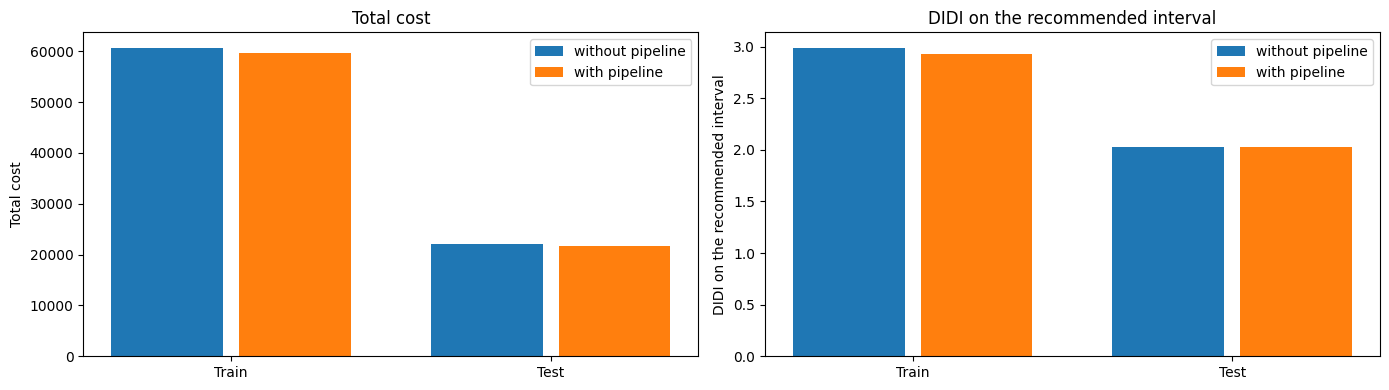

In [6]:
fig, axes = plt.subplots(1, 2, figsize=figsize)
for ax, metric, idx, ylabel in [
    (axes[0], 'total_cost', 0, 'Total cost'),
    (axes[1], 'didi', 2, 'DIDI on the recommended interval'),
]:
    for offset, variant in [(-0.2, 'without'), (0.2, 'with')]:
        values = [results[(split, variant)][idx] for split in ['Train', 'Test']]
        ax.bar([0 + offset, 1 + offset], values, width=0.35, label=f'{variant} pipeline')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Train', 'Test'])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
plt.tight_layout()
plt.show()

**Read the bars above as one question, does blending in Method B's health index move total cost or DIDI enough to matter, not as a new policy competing with snapshot adaptive.** They share the same menu, the same cost parameters, and, wherever a match existed, the same underlying visit, only RISK_SCORE itself differs between the two bars in each pair.

<a id="sec6"></a>

## 6. How Much Would These Numbers Move

Every number in the chart above comes from one fixed sample of patients, the actual train and test split, and only for the with pipeline run, the without pipeline run above is a reference point for this notebook's own reading, not a second result competing for its own interval. bootstrap_ci resamples patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, recomputes the same metric on each resample, and reads the 2.5th and 97.5th percentile as a 95 percent interval.

Wide or narrow, this interval says nothing about whether the number is good, only how much of it is signal against a different sample versus noise from this particular one, useful together with comparison.ipynb's own reading across all four interval policies, not instead of it.

Train, total cost 59644.1, 95% CI [57654.0, 61863.8]
Test,  total cost 21640.9, 95% CI [20536.5, 22818.6]
Train, catch rate 97.8%, 95% CI [96.4, 98.9]
Test,  catch rate 99.0%, 95% CI [97.1, 100.0]


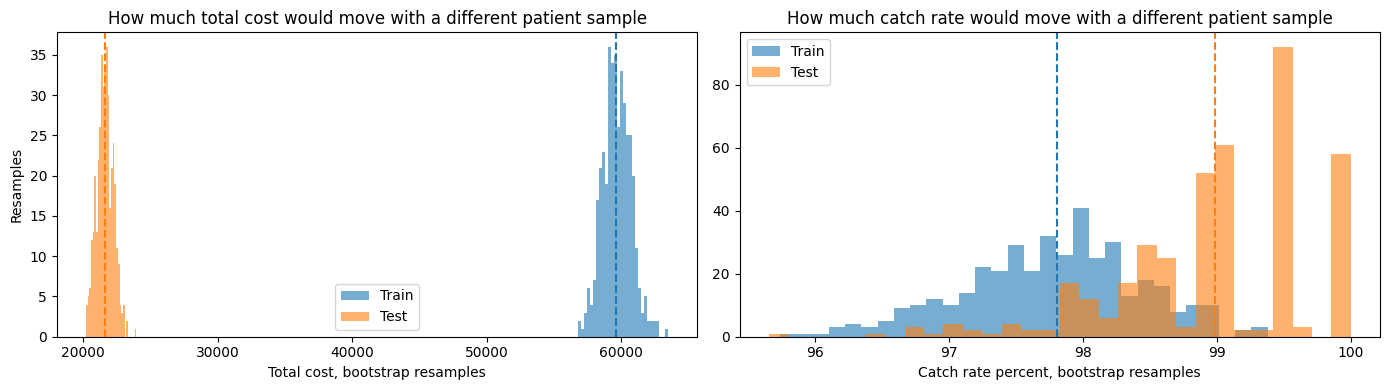

In [7]:
def cost_metric(d):
    d = d.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    recommended = du.recommend_interval(
        d['RISK_SCORE_PIPELINE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=MISSED_CONVERSION_COST,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    total_cost, _, _ = cmodel.cost(
        rid_ids=d['RID'].values, risk_scores=d['RISK_SCORE_PIPELINE'].values,
        threshold=0.5, interval_months=recommended, return_margin=False,
    )
    return total_cost

def didi_metric(d):
    d = d.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    recommended = du.recommend_interval(
        d['RISK_SCORE_PIPELINE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=MISSED_CONVERSION_COST,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    return du.compute_didi(d, recommended, make_protected(d))

def catch_rate_metric(d):
    d = d.copy()
    d['PTEDUCAT_BUCKET'] = du.bucket_educat(d['PTEDUCAT'], split_at=16)
    recommended = du.recommend_interval(
        d['RISK_SCORE_PIPELINE'].values, interval_menu_months=(3, 6, 12),
        check_cost=CHECK_COST, missed_conversion_cost=MISSED_CONVERSION_COST,
        reference_interval_months=REFERENCE_INTERVAL_MONTHS,
    )
    outcomes = du.compute_diagnosis_worsening(d, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS')
    outcomes['RECOMMENDED_INTERVAL'] = recommended
    worsened = outcomes['HAS_NEXT_VISIT'] & outcomes['DIAGNOSIS_WORSENED_NEXT']
    margin = outcomes.loc[worsened, 'NEXT_VISIT_GAP_MONTHS'] - outcomes.loc[worsened, 'RECOMMENDED_INTERVAL']
    return (margin >= 0).mean() * 100

train_cost_point, train_cost_lo, train_cost_hi, train_cost_samples = du.bootstrap_ci(train_df, cost_metric, id_col='RID')
test_cost_point, test_cost_lo, test_cost_hi, test_cost_samples = du.bootstrap_ci(test_df, cost_metric, id_col='RID')
train_didi_point, train_didi_lo, train_didi_hi, _ = du.bootstrap_ci(train_df, didi_metric, id_col='RID')
test_didi_point, test_didi_lo, test_didi_hi, _ = du.bootstrap_ci(test_df, didi_metric, id_col='RID')
train_catch_point, train_catch_lo, train_catch_hi, train_catch_samples = du.bootstrap_ci(train_df, catch_rate_metric, id_col='RID')
test_catch_point, test_catch_lo, test_catch_hi, test_catch_samples = du.bootstrap_ci(test_df, catch_rate_metric, id_col='RID')

print(f'Train, total cost {train_cost_point:.1f}, 95% CI [{train_cost_lo:.1f}, {train_cost_hi:.1f}]')
print(f'Test,  total cost {test_cost_point:.1f}, 95% CI [{test_cost_lo:.1f}, {test_cost_hi:.1f}]')
print(f'Train, catch rate {train_catch_point:.1f}%, 95% CI [{train_catch_lo:.1f}, {train_catch_hi:.1f}]')
print(f'Test,  catch rate {test_catch_point:.1f}%, 95% CI [{test_catch_lo:.1f}, {test_catch_hi:.1f}]')

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(train_cost_samples, bins=30, alpha=0.6, label='Train')
axes[0].hist(test_cost_samples, bins=30, alpha=0.6, label='Test')
axes[0].axvline(train_cost_point, color='C0', linestyle='--')
axes[0].axvline(test_cost_point, color='C1', linestyle='--')
axes[0].set_xlabel('Total cost, bootstrap resamples')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much total cost would move with a different patient sample')
axes[0].legend()

axes[1].hist(train_catch_samples, bins=30, alpha=0.6, label='Train')
axes[1].hist(test_catch_samples, bins=30, alpha=0.6, label='Test')
axes[1].axvline(train_catch_point, color='C0', linestyle='--')
axes[1].axvline(test_catch_point, color='C1', linestyle='--')
axes[1].set_xlabel('Catch rate percent, bootstrap resamples')
axes[1].set_title('How much catch rate would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec7"></a>

## 7. Saving The Standardized Result

Logged into the same interval policy group as the other three policies, so comparison.ipynb's own chart and cheapest policy line for that group pick this row up automatically alongside fixed_policy, snapshot_adaptive, and trajectory_adaptive. The with pipeline run's own catch rate is logged alongside total cost and DIDI, the without pipeline run above is for this notebook's own side by side reading only, it is not saved to the shared file, only the with pipeline row ever competes for cheapest policy in comparison.ipynb. The confidence intervals from the section above are logged alongside the point estimates, on the with pipeline row only.

In [8]:
train_cost, train_over, train_didi, train_catch_rate = results[('Train', 'with')]
test_cost, test_over, test_didi, test_catch_rate = results[('Test', 'with')]

train_ci = {
    'total_cost': (train_cost_lo, train_cost_hi),
    'didi': (train_didi_lo, train_didi_hi),
    'catch_rate': (train_catch_lo, train_catch_hi),
}
test_ci = {
    'total_cost': (test_cost_lo, test_cost_hi),
    'didi': (test_didi_lo, test_didi_hi),
    'catch_rate': (test_catch_lo, test_catch_hi),
}

du.append_approach_result(
    results_path, approach='pipeline_health_index', approach_group='interval_policy',
    split='train', n_rows=len(train_df), total_cost=train_cost,
    over_threshold_count=train_over, didi=train_didi,
    catch_rate=train_catch_rate, ci=train_ci,
    notes=f'Snapshot adaptive policy on RISK_SCORE blended 80/20 with Method B HI, '
          f'matched by RID and nearest exam date within 180 days, {hi_coverage:.1%} coverage.',
)
result_row = du.append_approach_result(
    results_path, approach='pipeline_health_index', approach_group='interval_policy',
    split='test', n_rows=len(test_df), total_cost=test_cost,
    over_threshold_count=test_over, didi=test_didi,
    catch_rate=test_catch_rate, ci=test_ci,
    notes=f'Snapshot adaptive policy on RISK_SCORE blended 80/20 with Method B HI, '
          f'matched by RID and nearest exam date within 180 days, {hi_coverage:.1%} coverage.',
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,total_cost_ci_high,didi_ci_low,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,notes
0,unconstrained,fairness_correction,train,2048,NaN,NaN,0.084095,NaN,0.344772,0.175168,...,NaN,0.041680,0.143551,NaN,NaN,0.265260,0.417322,0.164100,0.184926,"No fairness constraint, this is the accuracy c..."
1,unconstrained,fairness_correction,test,753,NaN,NaN,0.128358,NaN,0.056403,0.211343,...,NaN,0.039131,0.249323,NaN,NaN,-0.243365,0.267490,0.188433,0.235709,"No fairness constraint, this is the accuracy c..."
2,fixed_lambda,fairness_correction,train,2048,NaN,NaN,0.029024,NaN,-0.046617,0.212322,...,NaN,0.008494,0.118877,NaN,NaN,-0.187824,0.102449,0.197038,0.225648,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
3,fixed_lambda,fairness_correction,test,753,NaN,NaN,0.048055,NaN,-0.290264,0.232721,...,NaN,0.016483,0.184842,NaN,NaN,-0.655570,-0.016109,0.203698,0.262560,"Fixed Lagrangian multiplier alpha=5.0, DIDI th..."
4,dual_lambda,fairness_correction,train,2048,NaN,NaN,0.042104,NaN,0.336206,0.177150,...,NaN,0.010990,0.104270,NaN,NaN,0.260946,0.409193,0.166429,0.186627,Learned Lagrangian multiplier via gradient asc...
5,dual_lambda,fairness_correction,test,753,NaN,NaN,0.122326,NaN,0.067258,0.210892,...,NaN,0.037218,0.238245,NaN,NaN,-0.230993,0.278277,0.186855,0.236561,Learned Lagrangian multiplier via gradient asc...
6,fixed_policy,interval_policy,train,10162,69237.500000,6228.0,0.000000,87.624750,NaN,NaN,...,71548.762500,0.000000,0.000000,84.470825,90.437107,NaN,NaN,NaN,NaN,"No patient information used, same interval for..."
7,fixed_policy,interval_policy,test,3665,25176.500000,2271.0,0.000000,90.862944,NaN,NaN,...,26630.137500,0.000000,0.000000,86.696483,94.767083,NaN,NaN,NaN,NaN,"No patient information used, same interval for..."
8,snapshot_adaptive,interval_policy,train,10162,60693.250000,6228.0,2.989098,97.804391,NaN,NaN,...,62554.968750,2.026882,4.206785,96.385360,99.000296,NaN,NaN,NaN,NaN,Predict then Optimize on the current visit RIS...
9,snapshot_adaptive,interval_policy,test,3665,22035.750000,2271.0,2.028117,98.984772,NaN,NaN,...,23267.337500,1.287859,4.780352,97.474427,100.000000,NaN,NaN,NaN,NaN,Predict then Optimize on the current visit RIS...


<a id="sec8"></a>

## 8. Takeaways

**This is one input, added on its own, not the finished pipeline.**

> **Status note, pending other tracks, resolve then delete:** the RUL track does not have a per row prediction to merge in yet, `rul_results.csv` currently holds a modality comparison instead, the natural second notebook once that export exists is the same pattern again, one more input, compared with and without. The fairness and explainability questions this blended score should eventually be checked against are also left to a joint pass with the anomaly detection track rather than attempted in this one notebook alone.